# 3.  Codificación de variables

Conjunto de datos: titanic (incluido en seaborn)

Este conjunto de datos es excelente para trabajar con variables categóricas.

In [1]:
# Importar librerías necesarias
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

In [2]:
# Cargar el conjunto de datos
data = sns.load_dataset('titanic')

In [3]:
# Visualizar las primeras filas
print("Conjunto de datos Titanic:")
data.head()

Conjunto de datos Titanic:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
# Seleccionar columnas categóricas
categorical_cols = ['sex', 'embarked', 'class']

In [5]:
# Codificar con LabelEncoder
label_encoder = LabelEncoder()
data['sex_label'] = label_encoder.fit_transform(data['sex'])

In [6]:
# Codificar con OneHotEncoder
onehot_encoder = pd.get_dummies(data['embarked'], prefix='embarked')

In [7]:
# Combinar con el conjunto original
data = pd.concat([data, onehot_encoder], axis=1)

# Ejercicios
Contesta las siguientes preguntas. Para cada pregunta, deberás escribir código que demostrará cómo llegaste al resultado. Crea gráficas en donde veas correcto.

### 1. ¿Qué diferencias encuentras entre LabelEncoder y OneHotEncoder?

In [8]:
print("LabelEncoder convierte cada categoría en un número entero único.")
print("Por ejemplo, 'male' -> 1 y 'female' -> 0 en la columna sex_label.")
print("OneHotEncoder/`get_dummies` crea columnas binarias separadas para cada categoría.")
print("Esto evita que el modelo interprete un orden o jerarquía entre categorías.")

print("\nEjemplo de LabelEncoder en sex:")
print(data[['sex', 'sex_label']].head())

print("\nEjemplo de OneHotEncoder en embarked:")
print(data[['embarked', 'embarked_C', 'embarked_Q', 'embarked_S']].head())

LabelEncoder convierte cada categoría en un número entero único.
Por ejemplo, 'male' -> 1 y 'female' -> 0 en la columna sex_label.
OneHotEncoder/`get_dummies` crea columnas binarias separadas para cada categoría.
Esto evita que el modelo interprete un orden o jerarquía entre categorías.

Ejemplo de LabelEncoder en sex:
      sex  sex_label
0    male          1
1  female          0
2  female          0
3  female          0
4    male          1

Ejemplo de OneHotEncoder en embarked:
  embarked  embarked_C  embarked_Q  embarked_S
0        S       False       False        True
1        C        True       False       False
2        S       False       False        True
3        S       False       False        True
4        S       False       False        True


### 2. Crea una gráfica de barras comparando las frecuencias de 'sex' antes y después de la codificación con LabelEncoder.

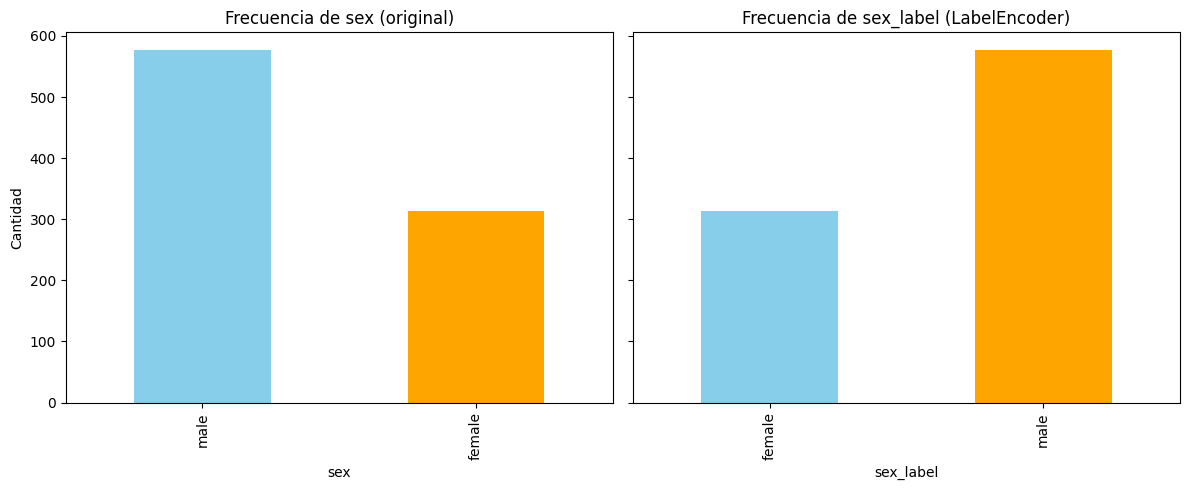

In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# Frecuencias originales
data['sex'].value_counts().plot(kind='bar', ax=axes[0], color=['skyblue', 'orange'])
axes[0].set_title('Frecuencia de sex (original)')
axes[0].set_xlabel('sex')
axes[0].set_ylabel('Cantidad')

# Frecuencias codificadas
data['sex_label'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color=['skyblue', 'orange'])
axes[1].set_title('Frecuencia de sex_label (LabelEncoder)')
axes[1].set_xlabel('sex_label')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['female', 'male'])

plt.tight_layout()
plt.show()

### 3. Utiliza OneHotEncoder para codificar la columna 'class'. ¿Qué ventajas tiene este enfoque frente a LabelEncoder?

In [10]:
# Codificar la columna 'class' con OneHotEncoder usando get_dummies
class_onehot = pd.get_dummies(data['class'], prefix='class')
print(class_onehot.head())

print("\nVentajas de OneHotEncoder frente a LabelEncoder:")
print("- No introduce orden implícito entre categorías.")
print("- Cada categoría se representa por una columna separada.")
print("- Es mejor para algoritmos lineales y basados en distancia porque evita relaciones ordinales artificiales.")

   class_First  class_Second  class_Third
0        False         False         True
1         True         False        False
2        False         False         True
3         True         False        False
4        False         False         True

Ventajas de OneHotEncoder frente a LabelEncoder:
- No introduce orden implícito entre categorías.
- Cada categoría se representa por una columna separada.
- Es mejor para algoritmos lineales y basados en distancia porque evita relaciones ordinales artificiales.


### 4. Si quisieras aplicar un modelo de aprendizaje automático, ¿qué tipo de codificación elegirías para las variables categóricas? Explica tu respuesta.

In [11]:
print("Para un modelo de aprendizaje automático típicamente elegiría OneHotEncoder para variables nominales como 'embarked' y 'class'.")
print("Esto evita que el modelo interprete un orden donde no lo hay y mejora el rendimiento en muchos algoritmos.")
print("LabelEncoder puede ser útil para variables ordinales o cuando se usan árboles, pero en general OneHot es más seguro para datos categóricos no ordenados.")

Para un modelo de aprendizaje automático típicamente elegiría OneHotEncoder para variables nominales como 'embarked' y 'class'.
Esto evita que el modelo interprete un orden donde no lo hay y mejora el rendimiento en muchos algoritmos.
LabelEncoder puede ser útil para variables ordinales o cuando se usan árboles, pero en general OneHot es más seguro para datos categóricos no ordenados.
